# Champion MLP Hyperparameter Analysis
## Systematic Comparison of Champion Architectures on QuickDraw (15 classes)

Each experiment varies **one key dimension** while keeping others controlled:
| Experiment Group | What Changes | Variants |
|---|---|---|
| **Activation Functions** | ReLU, GELU, LeakyReLU, SiLU, ELU, Tanh | 6 |
| **Layer Depth** | 2, 3, 4, 6, 8 hidden layers | 5 |
| **Learning Rate** | 0.0001 → 0.01 | 5 |
| **Loss Functions** | CE, CE+Smoothing, Focal Loss | 6 |
| **Optimizers** | Adam, AdamW, SGD, RMSprop | 4 |
| **Epoch Budget** | 10, 20, 30, 40 | 4 |

**Constraints:** < 3M parameters (less is better), ≤ 40 epochs

In [1]:
# ============================================================
# Imports & Device Setup
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
import torchvision.transforms as T

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import OrderedDict
import time, copy, os

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
# ============================================================
# Load QuickDraw Data & Create DataLoaders
# ============================================================
train_data = np.load(r"DL_PA2\processed_data\quickdraw_train.npz")
test_data = np.load(r"DL_PA2\processed_data\quickdraw_test.npz")

X_train = train_data['x_train'].astype(np.float32) / 255.0
y_train = train_data['y_train']
class_names = train_data['class_names']
X_test = test_data['test_images'].astype(np.float32) / 255.0

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Classes: {len(class_names)}")

class QuickDrawDataset(Dataset):
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment
        self.transform = T.Compose([
            T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.85, 1.15)),
            T.RandomErasing(p=0.2, scale=(0.02, 0.1)),
        ])
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.augment:
            image = torch.tensor(image.reshape(1, 28, 28), dtype=torch.float32)
            image = self.transform(image)
            image = image.reshape(-1)
        else:
            image = torch.tensor(image.reshape(-1), dtype=torch.float32)
        return image, torch.tensor(label, dtype=torch.long)

train_aug = QuickDrawDataset(X_train, y_train, augment=True)
val_clean = QuickDrawDataset(X_train, y_train, augment=False)

total = len(train_aug)
train_size = int(0.8 * total)
val_size = total - train_size

gen = torch.Generator().manual_seed(42)
train_idx, val_idx = random_split(range(total), [train_size, val_size], generator=gen)

train_dataset = Subset(train_aug, train_idx.indices)
val_dataset = Subset(val_clean, val_idx.indices)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {len(train_dataset)} (augmented) | Val: {len(val_dataset)} (clean)")

Train: (60000, 784), Test: (15000, 784), Classes: 15
Train: 48000 (augmented) | Val: 12000 (clean)


In [3]:
# ============================================================
# Flexible MLP Class + Focal Loss + Training Function
# ============================================================

class FlexibleMLP(nn.Module):
    """Configurable MLP: variable depth, width, activation, dropout, batch norm."""
    ACTIVATIONS = {
        'relu':       lambda: nn.ReLU(),
        'gelu':       lambda: nn.GELU(),
        'leaky_relu': lambda: nn.LeakyReLU(0.1),
        'silu':       lambda: nn.SiLU(),
        'elu':        lambda: nn.ELU(),
        'tanh':       lambda: nn.Tanh(),
    }

    def __init__(self, input_size=784, hidden_layers=[512, 256, 128, 64],
                 num_classes=15, activation='gelu', dropout=0.2,
                 use_batchnorm=True, progressive_dropout=False):
        super().__init__()
        layers = []
        prev = input_size
        n = len(hidden_layers)
        for i, h in enumerate(hidden_layers):
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(self.ACTIVATIONS[activation]())
            drop_rate = dropout * (i + 1) / n if progressive_dropout else dropout
            if drop_rate > 0:
                layers.append(nn.Dropout(drop_rate))
            prev = h
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.classifier(self.features(x))

    def count_params(self):
        return sum(p.numel() for p in self.parameters())


class FocalLoss(nn.Module):
    """Focal Loss — down-weights easy examples, focuses on hard ones."""
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none',
                              label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean() if self.alpha is None else (self.alpha * loss).mean()


def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, epochs=40, device='cuda', name='Model',
                grad_clip=1.0, verbose=True):
    """Universal training function — returns full history dict."""
    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [],
               'best_val_acc': 0, 'best_epoch': 0, 'train_time': 0}
    best_state = None
    start = time.time()

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        correct, total, running = 0, 0, 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            if grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
            optimizer.step()
            running += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
        history['train_loss'].append(running / total)
        history['train_acc'].append(100.0 * correct / total)

        # --- Validate ---
        model.eval()
        correct, total, running = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running += loss.item() * images.size(0)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item()
                total += labels.size(0)
        history['val_loss'].append(running / total)
        history['val_acc'].append(100.0 * correct / total)

        if scheduler:
            scheduler.step()
        if history['val_acc'][-1] > history['best_val_acc']:
            history['best_val_acc'] = history['val_acc'][-1]
            history['best_epoch'] = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        if verbose:
            lr = optimizer.param_groups[0]['lr']
            print(f"  [{name}] Ep {epoch+1:02d}/{epochs} | "
                  f"Train: {history['train_acc'][-1]:.2f}% | "
                  f"Val: {history['val_acc'][-1]:.2f}% | LR: {lr:.6f}")

    history['train_time'] = time.time() - start
    if best_state:
        model.load_state_dict(best_state)
    if verbose:
        print(f"  >> {name} — Best Val: {history['best_val_acc']:.2f}% @ epoch {history['best_epoch']} "
              f"({history['train_time']:.1f}s)\n")
    return history

# Quick sanity check
m = FlexibleMLP(); print(f"Default 4-layer MLP params: {m.count_params():,}"); del m

Default 4-layer MLP params: 577,295


---
## Experiment A: Activation Functions
**Fixed:** 4 layers [512→256→128→64], AdamW lr=0.001, CE+smoothing(0.1), 40 epochs, progressive dropout(0.2), BatchNorm  
**Varied:** ReLU, GELU, LeakyReLU, SiLU, ELU, Tanh

In [4]:
# ============================================================
# EXPERIMENT A: ACTIVATION FUNCTIONS
# ============================================================
activation_configs = {
    'ReLU': 'relu', 'GELU': 'gelu', 'LeakyReLU': 'leaky_relu',
    'SiLU': 'silu', 'ELU': 'elu', 'Tanh': 'tanh',
}
results_activation = {}

for name, act in activation_configs.items():
    print(f"\n{'='*60}\nTraining Champion with {name} activation\n{'='*60}")
    model = FlexibleMLP(hidden_layers=[512, 256, 128, 64], activation=act,
                        dropout=0.2, use_batchnorm=True, progressive_dropout=True)
    print(f"  Parameters: {model.count_params():,}")
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)
    history = train_model(model, train_loader, val_loader, criterion, optimizer,
                          scheduler=scheduler, epochs=40, device=device, name=name)
    history['params'] = model.count_params()
    history['model'] = model
    results_activation[name] = history

print("\n--- Activation Function Results ---")
for name, h in results_activation.items():
    print(f"  {name:12s} -> Best Val: {h['best_val_acc']:.2f}% (epoch {h['best_epoch']})")


Training Champion with ReLU activation
  Parameters: 577,295
  [ReLU] Ep 01/40 | Train: 48.08% | Val: 65.13% | LR: 0.000998
  [ReLU] Ep 02/40 | Train: 58.32% | Val: 69.60% | LR: 0.000994
  [ReLU] Ep 03/40 | Train: 61.49% | Val: 71.94% | LR: 0.000986
  [ReLU] Ep 04/40 | Train: 63.65% | Val: 72.76% | LR: 0.000976
  [ReLU] Ep 05/40 | Train: 65.04% | Val: 74.33% | LR: 0.000962
  [ReLU] Ep 06/40 | Train: 66.20% | Val: 74.91% | LR: 0.000946
  [ReLU] Ep 07/40 | Train: 67.00% | Val: 75.67% | LR: 0.000926
  [ReLU] Ep 08/40 | Train: 68.16% | Val: 76.22% | LR: 0.000905
  [ReLU] Ep 09/40 | Train: 68.41% | Val: 76.76% | LR: 0.000880
  [ReLU] Ep 10/40 | Train: 69.30% | Val: 77.28% | LR: 0.000854
  [ReLU] Ep 11/40 | Train: 70.07% | Val: 78.01% | LR: 0.000825
  [ReLU] Ep 12/40 | Train: 70.54% | Val: 78.34% | LR: 0.000794
  [ReLU] Ep 13/40 | Train: 70.76% | Val: 78.95% | LR: 0.000761
  [ReLU] Ep 14/40 | Train: 71.46% | Val: 79.04% | LR: 0.000727
  [ReLU] Ep 15/40 | Train: 71.82% | Val: 79.41% | LR: 0.

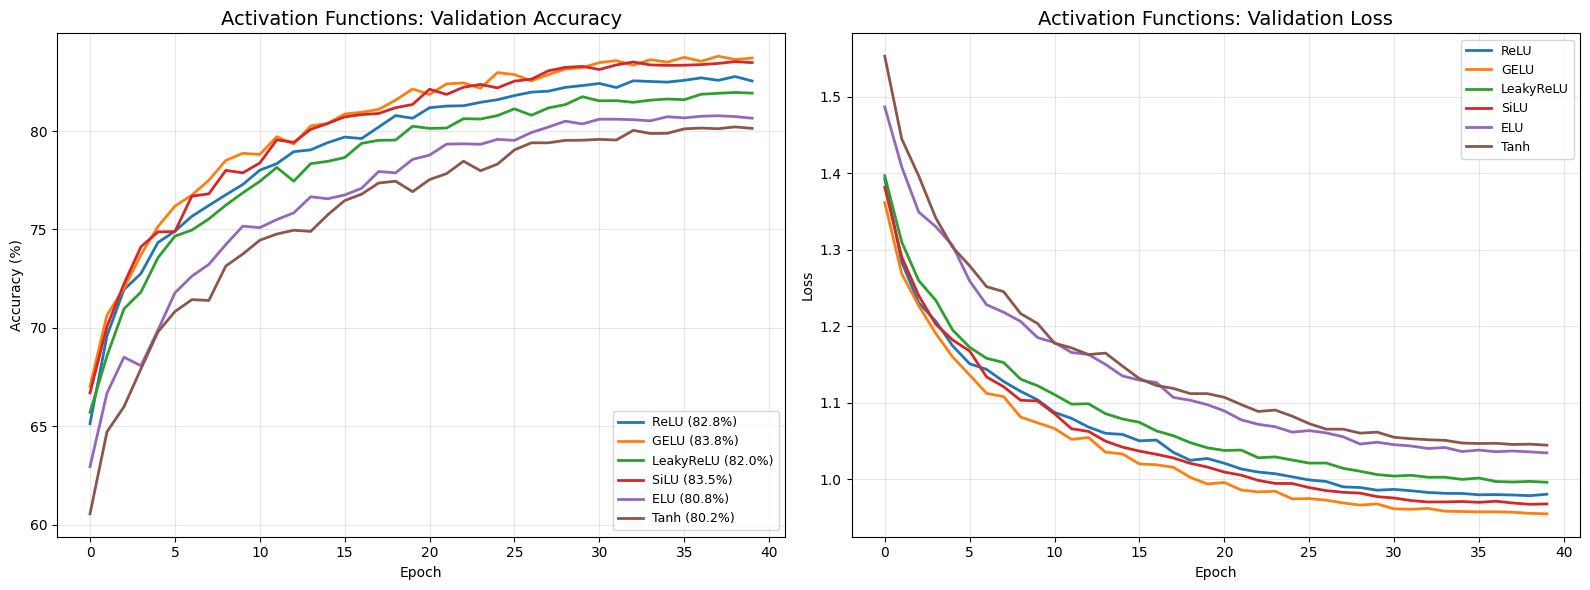

In [5]:
# Plot Activation Function Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_activation.items():
    axes[0].plot(h['val_acc'], label=f"{name} ({h['best_val_acc']:.1f}%)", linewidth=2)
    axes[1].plot(h['val_loss'], label=name, linewidth=2)
axes[0].set_title('Activation Functions: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Activation Functions: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Experiment B: Layer Depth
**Fixed:** GELU, AdamW lr=0.001, CE+smoothing(0.1), 40 epochs, progressive dropout(0.2), BatchNorm  
**Varied:** 2, 3, 4, 6, 8 hidden layers (widths adjusted to keep similar param range)

In [6]:
# ============================================================
# EXPERIMENT B: LAYER DEPTH
# ============================================================
depth_configs = {
    '2-Layer (768->256)':           [768, 256],
    '3-Layer (512->256->128)':      [512, 256, 128],
    '4-Layer (512->256->128->64)':  [512, 256, 128, 64],
    '6-Layer (384->256->256->192->128->64)': [384, 256, 256, 192, 128, 64],
    '8-Layer (256->224->192->192->160->128->96->64)': [256, 224, 192, 192, 160, 128, 96, 64],
}
results_depth = {}

for name, layers in depth_configs.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    model = FlexibleMLP(hidden_layers=layers, activation='gelu', dropout=0.2,
                        use_batchnorm=True, progressive_dropout=True)
    print(f"  Parameters: {model.count_params():,}")
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)
    history = train_model(model, train_loader, val_loader, criterion, optimizer,
                          scheduler=scheduler, epochs=40, device=device, name=name)
    history['params'] = model.count_params()
    history['model'] = model
    history['num_layers'] = len(layers)
    results_depth[name] = history

print("\n--- Layer Depth Results ---")
for name, h in results_depth.items():
    print(f"  {name:50s} -> Params: {h['params']:>8,} | Best Val: {h['best_val_acc']:.2f}%")


Training: 2-Layer (768->256)
  Parameters: 805,647
  [2-Layer (768->256)] Ep 01/40 | Train: 52.86% | Val: 69.18% | LR: 0.000998
  [2-Layer (768->256)] Ep 02/40 | Train: 61.50% | Val: 70.72% | LR: 0.000994
  [2-Layer (768->256)] Ep 03/40 | Train: 64.81% | Val: 73.92% | LR: 0.000986
  [2-Layer (768->256)] Ep 04/40 | Train: 66.40% | Val: 74.65% | LR: 0.000976
  [2-Layer (768->256)] Ep 05/40 | Train: 67.97% | Val: 76.87% | LR: 0.000962
  [2-Layer (768->256)] Ep 06/40 | Train: 68.94% | Val: 77.38% | LR: 0.000946
  [2-Layer (768->256)] Ep 07/40 | Train: 70.30% | Val: 77.36% | LR: 0.000926
  [2-Layer (768->256)] Ep 08/40 | Train: 70.94% | Val: 78.33% | LR: 0.000905
  [2-Layer (768->256)] Ep 09/40 | Train: 71.63% | Val: 79.45% | LR: 0.000880
  [2-Layer (768->256)] Ep 10/40 | Train: 72.41% | Val: 79.71% | LR: 0.000854
  [2-Layer (768->256)] Ep 11/40 | Train: 72.49% | Val: 80.03% | LR: 0.000825
  [2-Layer (768->256)] Ep 12/40 | Train: 73.06% | Val: 79.83% | LR: 0.000794
  [2-Layer (768->256)] E

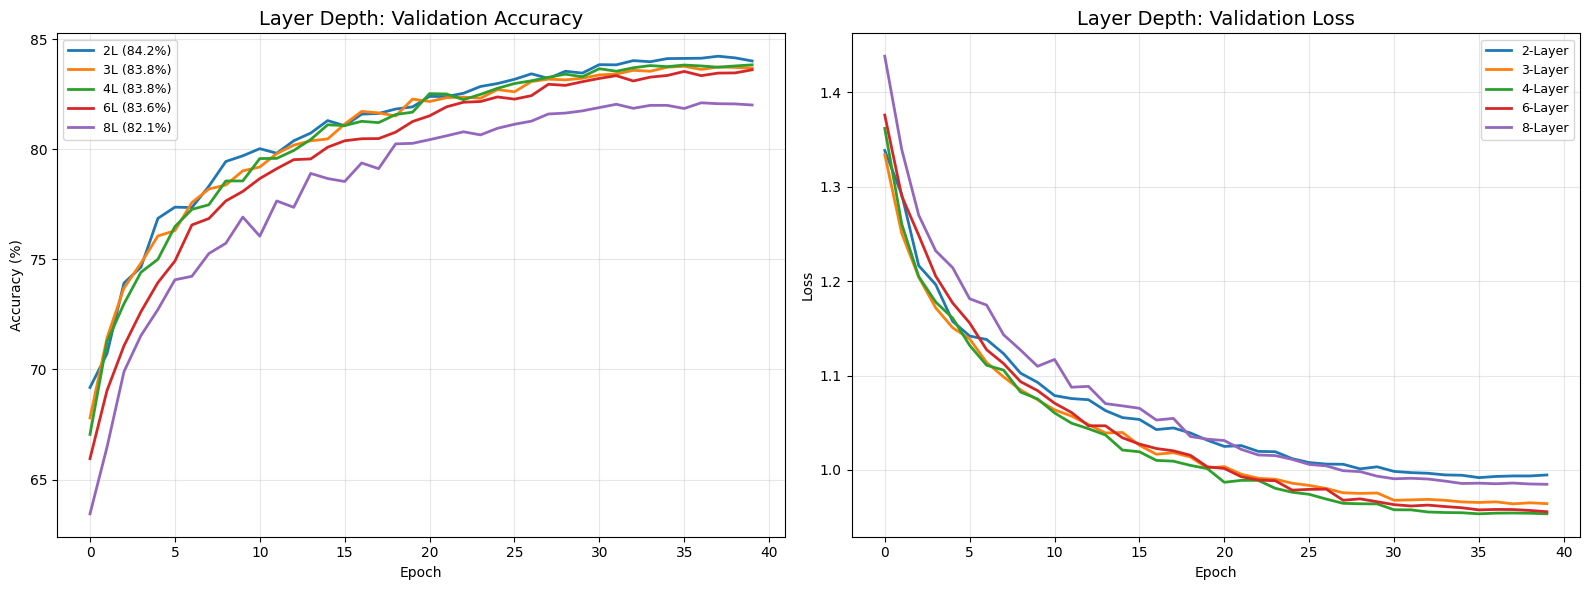

In [7]:
# Plot Layer Depth Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_depth.items():
    short = f"{h['num_layers']}L ({h['best_val_acc']:.1f}%)"
    axes[0].plot(h['val_acc'], label=short, linewidth=2)
    axes[1].plot(h['val_loss'], label=f"{h['num_layers']}-Layer", linewidth=2)
axes[0].set_title('Layer Depth: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Layer Depth: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Experiment C: Learning Rate
**Fixed:** 4 layers [512→256→128→64], GELU, AdamW, CE+smoothing(0.1), 40 epochs  
**Varied:** lr = 0.0001, 0.0005, 0.001, 0.003, 0.01

In [8]:
# ============================================================
# EXPERIMENT C: LEARNING RATE
# ============================================================
lr_configs = {
    'LR=0.0001': 0.0001, 'LR=0.0005': 0.0005, 'LR=0.001': 0.001,
    'LR=0.003': 0.003, 'LR=0.01': 0.01,
}
results_lr = {}

for name, lr in lr_configs.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    model = FlexibleMLP(hidden_layers=[512, 256, 128, 64], activation='gelu',
                        dropout=0.2, use_batchnorm=True, progressive_dropout=True)
    print(f"  Parameters: {model.count_params():,}")
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)
    history = train_model(model, train_loader, val_loader, criterion, optimizer,
                          scheduler=scheduler, epochs=40, device=device, name=name)
    history['params'] = model.count_params()
    history['lr'] = lr
    results_lr[name] = history

print("\n--- Learning Rate Results ---")
for name, h in results_lr.items():
    print(f"  {name:12s} -> Best Val: {h['best_val_acc']:.2f}% (epoch {h['best_epoch']})")


Training: LR=0.0001
  Parameters: 577,295
  [LR=0.0001] Ep 01/40 | Train: 33.80% | Val: 57.01% | LR: 0.000100
  [LR=0.0001] Ep 02/40 | Train: 48.89% | Val: 63.77% | LR: 0.000099
  [LR=0.0001] Ep 03/40 | Train: 54.54% | Val: 67.00% | LR: 0.000099
  [LR=0.0001] Ep 04/40 | Train: 57.17% | Val: 68.43% | LR: 0.000098
  [LR=0.0001] Ep 05/40 | Train: 59.05% | Val: 69.86% | LR: 0.000096
  [LR=0.0001] Ep 06/40 | Train: 60.53% | Val: 70.86% | LR: 0.000095
  [LR=0.0001] Ep 07/40 | Train: 61.79% | Val: 71.62% | LR: 0.000093
  [LR=0.0001] Ep 08/40 | Train: 62.64% | Val: 72.56% | LR: 0.000091
  [LR=0.0001] Ep 09/40 | Train: 63.43% | Val: 73.04% | LR: 0.000088
  [LR=0.0001] Ep 10/40 | Train: 64.32% | Val: 73.10% | LR: 0.000086
  [LR=0.0001] Ep 11/40 | Train: 64.56% | Val: 73.88% | LR: 0.000083
  [LR=0.0001] Ep 12/40 | Train: 65.12% | Val: 74.50% | LR: 0.000080
  [LR=0.0001] Ep 13/40 | Train: 65.67% | Val: 74.94% | LR: 0.000076
  [LR=0.0001] Ep 14/40 | Train: 66.31% | Val: 75.13% | LR: 0.000073
  [LR

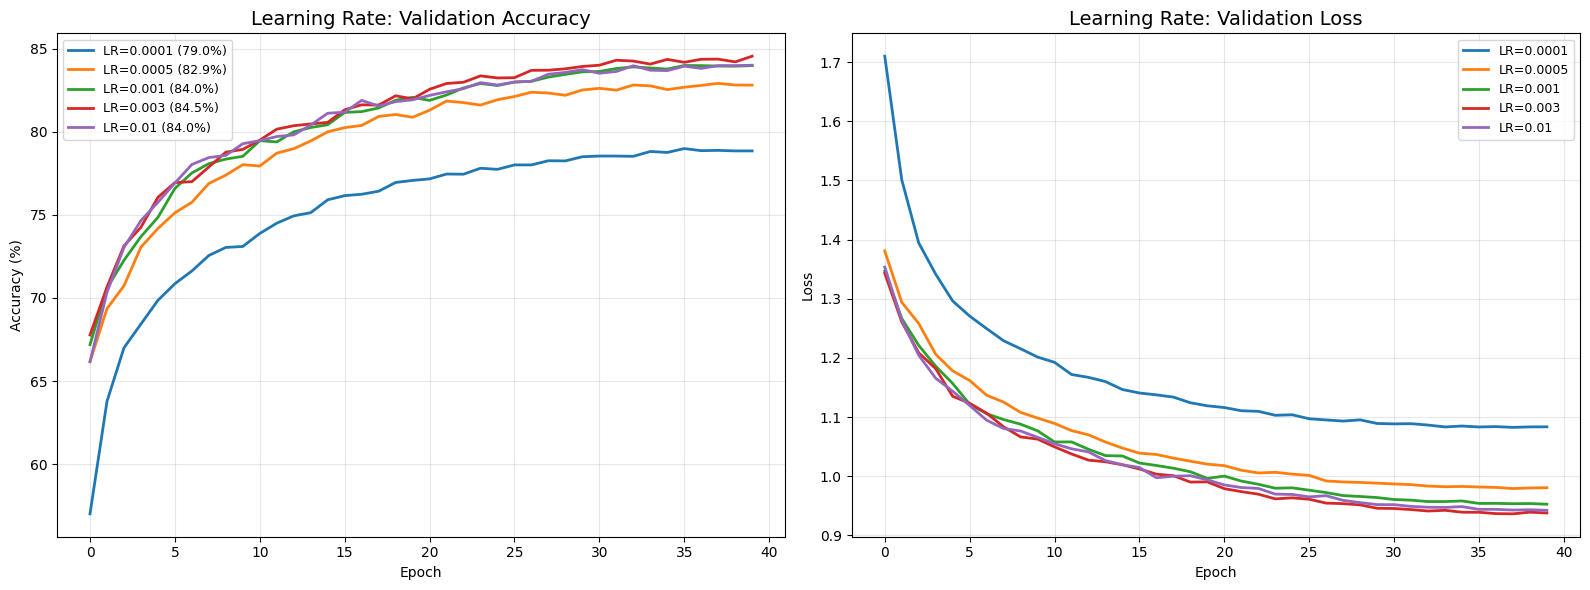

In [9]:
# Plot Learning Rate Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_lr.items():
    axes[0].plot(h['val_acc'], label=f"{name} ({h['best_val_acc']:.1f}%)", linewidth=2)
    axes[1].plot(h['val_loss'], label=name, linewidth=2)
axes[0].set_title('Learning Rate: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Learning Rate: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Experiment D: Loss Functions
**Fixed:** 4 layers [512→256→128→64], GELU, AdamW lr=0.001, 40 epochs  
**Varied:** CrossEntropy (plain), CE+LabelSmoothing(0.05/0.1/0.2), FocalLoss, Focal+Smoothing

In [10]:
# ============================================================
# EXPERIMENT D: LOSS FUNCTIONS
# ============================================================
loss_configs = {
    'CE (plain)':       nn.CrossEntropyLoss(),
    'CE+Smooth(0.05)':  nn.CrossEntropyLoss(label_smoothing=0.05),
    'CE+Smooth(0.1)':   nn.CrossEntropyLoss(label_smoothing=0.1),
    'CE+Smooth(0.2)':   nn.CrossEntropyLoss(label_smoothing=0.2),
    'Focal (g=2)':      FocalLoss(gamma=2.0),
    'Focal+Smooth':     FocalLoss(gamma=2.0, label_smoothing=0.1),
}
results_loss = {}

for name, criterion in loss_configs.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    model = FlexibleMLP(hidden_layers=[512, 256, 128, 64], activation='gelu',
                        dropout=0.2, use_batchnorm=True, progressive_dropout=True)
    print(f"  Parameters: {model.count_params():,}")
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)
    history = train_model(model, train_loader, val_loader, criterion, optimizer,
                          scheduler=scheduler, epochs=40, device=device, name=name)
    history['params'] = model.count_params()
    results_loss[name] = history

print("\n--- Loss Function Results ---")
for name, h in results_loss.items():
    print(f"  {name:20s} -> Best Val: {h['best_val_acc']:.2f}% (epoch {h['best_epoch']})")


Training: CE (plain)
  Parameters: 577,295
  [CE (plain)] Ep 01/40 | Train: 49.42% | Val: 66.92% | LR: 0.000998
  [CE (plain)] Ep 02/40 | Train: 59.24% | Val: 70.42% | LR: 0.000994
  [CE (plain)] Ep 03/40 | Train: 62.39% | Val: 72.71% | LR: 0.000986
  [CE (plain)] Ep 04/40 | Train: 64.54% | Val: 73.53% | LR: 0.000976
  [CE (plain)] Ep 05/40 | Train: 65.97% | Val: 74.67% | LR: 0.000962
  [CE (plain)] Ep 06/40 | Train: 67.37% | Val: 75.60% | LR: 0.000946
  [CE (plain)] Ep 07/40 | Train: 68.12% | Val: 76.92% | LR: 0.000926
  [CE (plain)] Ep 08/40 | Train: 69.16% | Val: 77.72% | LR: 0.000905
  [CE (plain)] Ep 09/40 | Train: 69.83% | Val: 77.71% | LR: 0.000880
  [CE (plain)] Ep 10/40 | Train: 70.48% | Val: 78.56% | LR: 0.000854
  [CE (plain)] Ep 11/40 | Train: 71.29% | Val: 78.69% | LR: 0.000825
  [CE (plain)] Ep 12/40 | Train: 71.73% | Val: 79.10% | LR: 0.000794
  [CE (plain)] Ep 13/40 | Train: 72.20% | Val: 79.92% | LR: 0.000761
  [CE (plain)] Ep 14/40 | Train: 72.53% | Val: 79.91% | LR:

KeyboardInterrupt: 

In [ ]:
# Plot Loss Function Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_loss.items():
    axes[0].plot(h['val_acc'], label=f"{name} ({h['best_val_acc']:.1f}%)", linewidth=2)
    axes[1].plot(h['val_loss'], label=name, linewidth=2)
axes[0].set_title('Loss Functions: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Loss Functions: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Experiment E: Optimizers
**Fixed:** 4 layers [512→256→128→64], GELU, CE+smoothing(0.1), 40 epochs  
**Varied:** Adam, AdamW, SGD+Momentum(0.9), RMSprop

In [ ]:
# ============================================================
# EXPERIMENT E: OPTIMIZERS
# ============================================================
optim_configs = OrderedDict({
    'Adam':         lambda p: optim.Adam(p, lr=0.001),
    'AdamW':        lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-3),
    'SGD+Momentum': lambda p: optim.SGD(p, lr=0.01, momentum=0.9, weight_decay=1e-4),
    'RMSprop':      lambda p: optim.RMSprop(p, lr=0.001, weight_decay=1e-4),
})
results_optim = {}

for name, opt_fn in optim_configs.items():
    print(f"\n{'='*60}\nTraining with {name}\n{'='*60}")
    model = FlexibleMLP(hidden_layers=[512, 256, 128, 64], activation='gelu',
                        dropout=0.2, use_batchnorm=True, progressive_dropout=True)
    print(f"  Parameters: {model.count_params():,}")
    optimizer = opt_fn(model.parameters())
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)
    history = train_model(model, train_loader, val_loader, criterion, optimizer,
                          scheduler=scheduler, epochs=40, device=device, name=name)
    history['params'] = model.count_params()
    results_optim[name] = history

print("\n--- Optimizer Results ---")
for name, h in results_optim.items():
    print(f"  {name:15s} -> Best Val: {h['best_val_acc']:.2f}% (epoch {h['best_epoch']})")

In [ ]:
# Plot Optimizer Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_optim.items():
    axes[0].plot(h['val_acc'], label=f"{name} ({h['best_val_acc']:.1f}%)", linewidth=2)
    axes[1].plot(h['val_loss'], label=name, linewidth=2)
axes[0].set_title('Optimizers: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Optimizers: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Experiment F: Epoch Budget (Convergence Speed)
**Fixed:** 4-layer GELU champion baseline config  
**Varied:** 10, 20, 30, 40 epochs — tests how fast each converges

In [ ]:
# ============================================================
# EXPERIMENT F: EPOCH BUDGET
# ============================================================
epoch_configs = {'10 Epochs': 10, '20 Epochs': 20, '30 Epochs': 30, '40 Epochs': 40}
results_epochs = {}

for name, num_epochs in epoch_configs.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    model = FlexibleMLP(hidden_layers=[512, 256, 128, 64], activation='gelu',
                        dropout=0.2, use_batchnorm=True, progressive_dropout=True)
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-3)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)
    history = train_model(model, train_loader, val_loader, criterion, optimizer,
                          scheduler=scheduler, epochs=num_epochs, device=device, name=name)
    history['params'] = model.count_params()
    history['epochs_trained'] = num_epochs
    results_epochs[name] = history

print("\n--- Epoch Budget Results ---")
for name, h in results_epochs.items():
    print(f"  {name:12s} -> Best Val: {h['best_val_acc']:.2f}% (epoch {h['best_epoch']}, {h['train_time']:.1f}s)")

In [ ]:
# Plot Epoch Budget Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_epochs.items():
    axes[0].plot(h['val_acc'], label=f"{name} ({h['best_val_acc']:.1f}%)", linewidth=2)
    axes[1].plot(h['val_loss'], label=name, linewidth=2)
axes[0].set_title('Epoch Budget: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Epoch Budget: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## Grand Comparison: All Experiments Summary

In [ ]:
# ============================================================
# GRAND COMPARISON TABLE
# ============================================================
all_results = {}
for name, h in results_activation.items():
    all_results[f"[Act] {name}"] = {**h, 'group': 'Activation', 'key_var': name}
for name, h in results_depth.items():
    all_results[f"[Depth] {name}"] = {**h, 'group': 'Depth', 'key_var': name}
for name, h in results_lr.items():
    all_results[f"[LR] {name}"] = {**h, 'group': 'Learning Rate', 'key_var': name}
for name, h in results_loss.items():
    all_results[f"[Loss] {name}"] = {**h, 'group': 'Loss Function', 'key_var': name}
for name, h in results_optim.items():
    all_results[f"[Opt] {name}"] = {**h, 'group': 'Optimizer', 'key_var': name}
for name, h in results_epochs.items():
    all_results[f"[Ep] {name}"] = {**h, 'group': 'Epoch Budget', 'key_var': name}

rows = []
for name, h in all_results.items():
    rows.append({
        'Champion': name,
        'Group': h['group'],
        'Params': h.get('params', 0),
        'Epochs': len(h['train_acc']),
        'Best Val Acc (%)': h['best_val_acc'],
        'Best Epoch': h['best_epoch'],
        'Final Train Acc (%)': h['train_acc'][-1],
        'Final Val Acc (%)': h['val_acc'][-1],
        'Train Time (s)': round(h['train_time'], 1),
        'Efficiency (Acc/M-params)': round(h['best_val_acc'] / max(h.get('params', 1) / 1e6, 0.001), 1)
    })

df = pd.DataFrame(rows).sort_values('Best Val Acc (%)', ascending=False).reset_index(drop=True)

print("=" * 120)
print("GRAND COMPARISON TABLE - ALL CHAMPION EXPERIMENTS")
print("=" * 120)
print(df.to_string(index=True))
print("=" * 120)
print(f"\nBEST OVERALL: {df.iloc[0]['Champion']} -> {df.iloc[0]['Best Val Acc (%)']:.2f}%")
print(f"Most Efficient: {df.sort_values('Efficiency (Acc/M-params)', ascending=False).iloc[0]['Champion']}")

In [ ]:
# ============================================================
# BAR CHARTS: Best Val Accuracy per Experiment Group
# ============================================================
experiment_groups = [
    ('Activation', results_activation), ('Depth', results_depth),
    ('Learning Rate', results_lr), ('Loss Function', results_loss),
    ('Optimizer', results_optim), ('Epoch Budget', results_epochs),
]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for idx, (group_name, res) in enumerate(experiment_groups):
    ax = axes[idx]
    names = list(res.keys())
    accs = [res[n]['best_val_acc'] for n in names]
    bars = ax.barh(names, accs, color=colors[idx], alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Best Val Accuracy (%)')
    ax.set_title(f'{group_name}', fontsize=13, fontweight='bold')
    ax.set_xlim(min(accs) - 2, max(accs) + 1.5)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{acc:.2f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Champion MLP Analysis: Best Validation Accuracy by Experiment Group',
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# SCATTER: Parameter Count vs Accuracy + Efficiency Ranking
# ============================================================
group_colors = {
    'Activation': '#2196F3', 'Depth': '#4CAF50', 'Learning Rate': '#FF9800',
    'Loss Function': '#E91E63', 'Optimizer': '#9C27B0', 'Epoch Budget': '#00BCD4'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

for _, row in df.iterrows():
    color = group_colors.get(row['Group'], 'gray')
    ax1.scatter(row['Params'] / 1e6, row['Best Val Acc (%)'],
                s=100, color=color, edgecolors='black', linewidth=0.5, zorder=5)
    ax1.annotate(row['Champion'].split('] ')[-1],
                 (row['Params']/1e6, row['Best Val Acc (%)']),
                 fontsize=6, ha='left', va='bottom', xytext=(3, 3), textcoords='offset points')

ax1.axvline(x=3.0, color='red', linestyle='--', linewidth=2, label='3M Param Limit')
ax1.set_xlabel('Parameters (Millions)', fontsize=12)
ax1.set_ylabel('Best Val Accuracy (%)', fontsize=12)
ax1.set_title('Accuracy vs Parameter Count', fontsize=14)
handles = [plt.Line2D([0],[0], marker='o', color=c, markersize=8, label=g, linestyle='None')
           for g, c in group_colors.items()]
handles.append(plt.Line2D([0],[0], color='red', linestyle='--', label='3M Limit'))
ax1.legend(handles=handles, fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.3)

eff = df.sort_values('Efficiency (Acc/M-params)', ascending=True)
ax2.barh(eff['Champion'], eff['Efficiency (Acc/M-params)'], color='#26A69A',
         edgecolor='black', linewidth=0.5)
ax2.set_xlabel('Efficiency (Accuracy / Million Params)', fontsize=12)
ax2.set_title('Parameter Efficiency Ranking', fontsize=14)
ax2.tick_params(axis='y', labelsize=7)
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# OVERLAY: Train vs Val Accuracy for ALL experiment groups
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

for idx, (group_name, res) in enumerate(experiment_groups):
    ax = axes[idx // 3, idx % 3]
    for name, h in res.items():
        ax.plot(h['train_acc'], linestyle='--', alpha=0.5, linewidth=1)
        ax.plot(h['val_acc'], linewidth=2.5, label=name)
    ax.set_title(f'{group_name}: Train (dashed) vs Val (solid)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Accuracy - All Experiment Groups',
             fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

In [11]:
# Extract summary results for report
print("=== ACTIVATION RESULTS ===")
for name, h in results_activation.items():
    print(f"  {name:12s} | Best Val: {h['best_val_acc']:.2f}% | Epoch: {h['best_epoch']} | Params: {h['params']:,}")

print("\n=== DEPTH RESULTS ===")
for name, h in results_depth.items():
    print(f"  {name:50s} | Best Val: {h['best_val_acc']:.2f}% | Epoch: {h['best_epoch']} | Params: {h['params']:,}")

print("\n=== LEARNING RATE RESULTS ===")
for name, h in results_lr.items():
    print(f"  {name:12s} | Best Val: {h['best_val_acc']:.2f}% | Epoch: {h['best_epoch']}")

=== ACTIVATION RESULTS ===
  ReLU         | Best Val: 82.77% | Epoch: 39 | Params: 577,295
  GELU         | Best Val: 83.80% | Epoch: 38 | Params: 577,295
  LeakyReLU    | Best Val: 81.96% | Epoch: 39 | Params: 577,295
  SiLU         | Best Val: 83.53% | Epoch: 39 | Params: 577,295
  ELU          | Best Val: 80.78% | Epoch: 38 | Params: 577,295
  Tanh         | Best Val: 80.21% | Epoch: 39 | Params: 577,295

=== DEPTH RESULTS ===
  2-Layer (768->256)                                 | Best Val: 84.23% | Epoch: 38 | Params: 805,647
  3-Layer (512->256->128)                            | Best Val: 83.78% | Epoch: 36 | Params: 569,871
  4-Layer (512->256->128->64)                        | Best Val: 83.84% | Epoch: 40 | Params: 577,295
  6-Layer (384->256->256->192->128->64)              | Best Val: 83.62% | Epoch: 40 | Params: 551,631
  8-Layer (256->224->192->192->160->128->96->64)     | Best Val: 82.12% | Epoch: 37 | Params: 412,463

=== LEARNING RATE RESULTS ===
  LR=0.0001    | Best Val

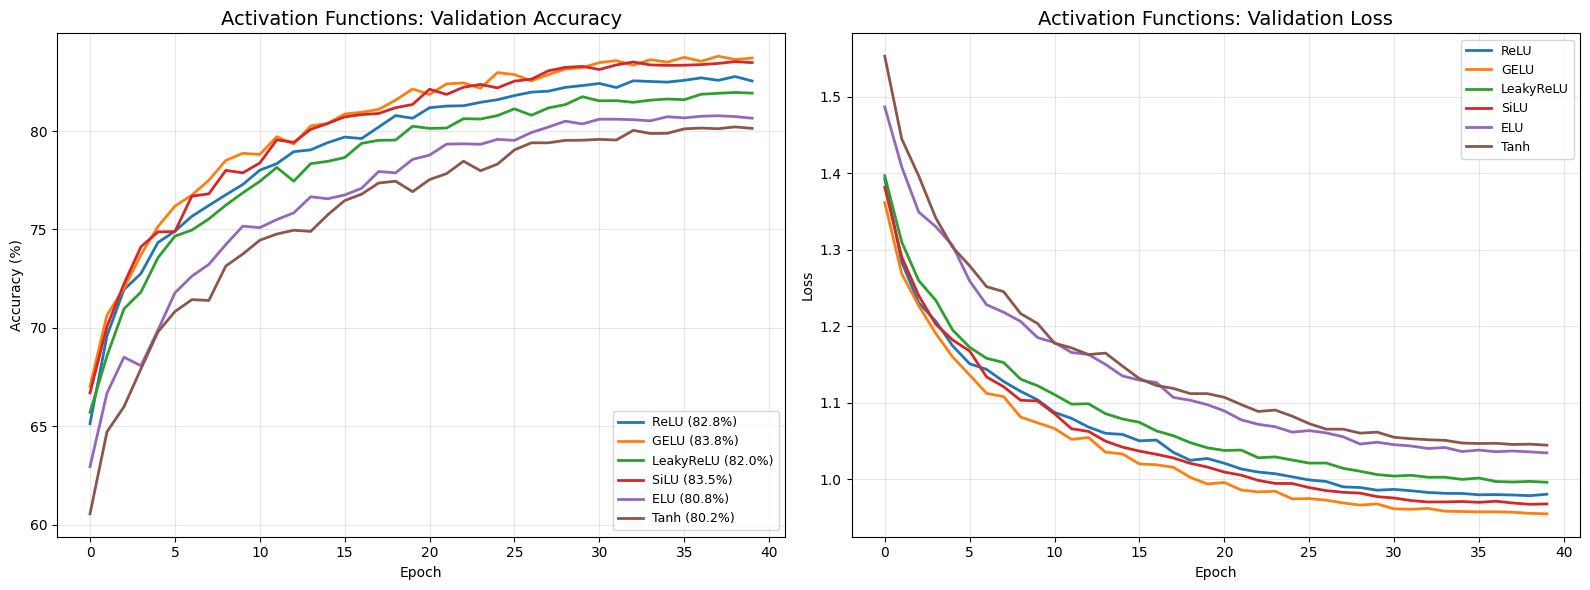

Saved analysis/exp_activations.png


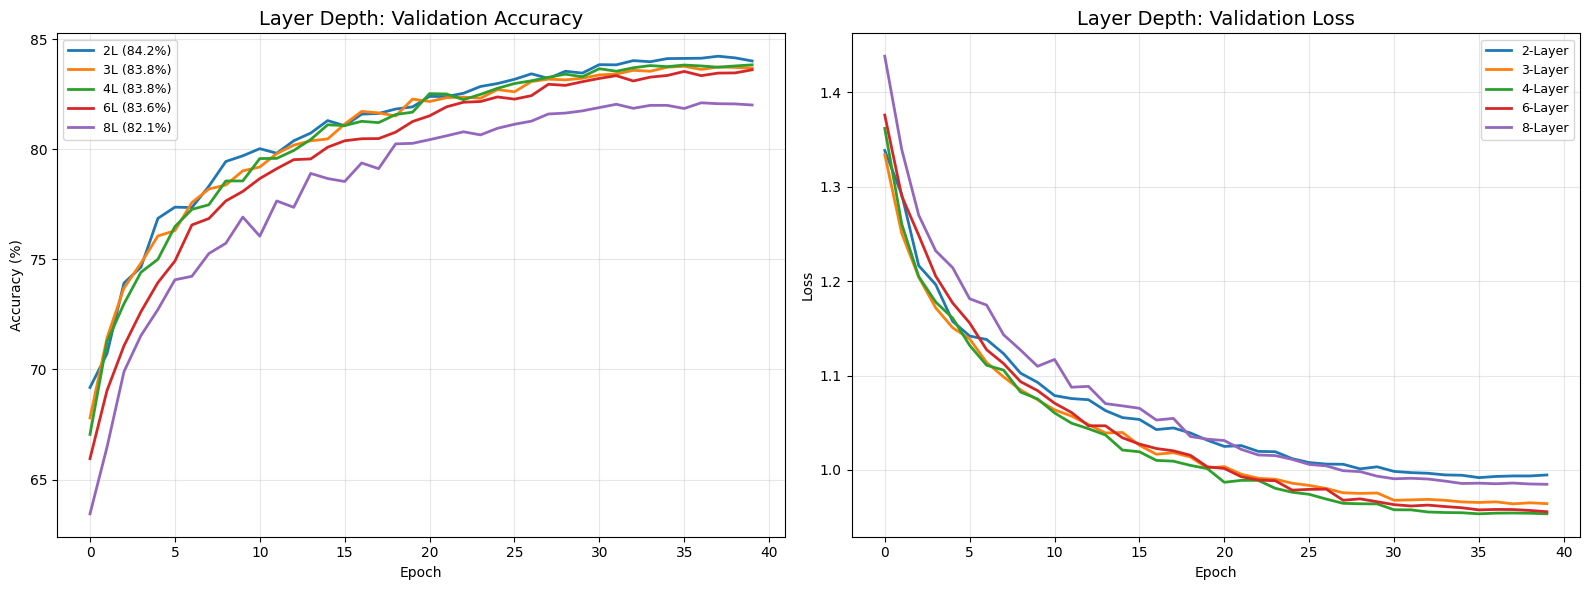

Saved analysis/exp_depth.png


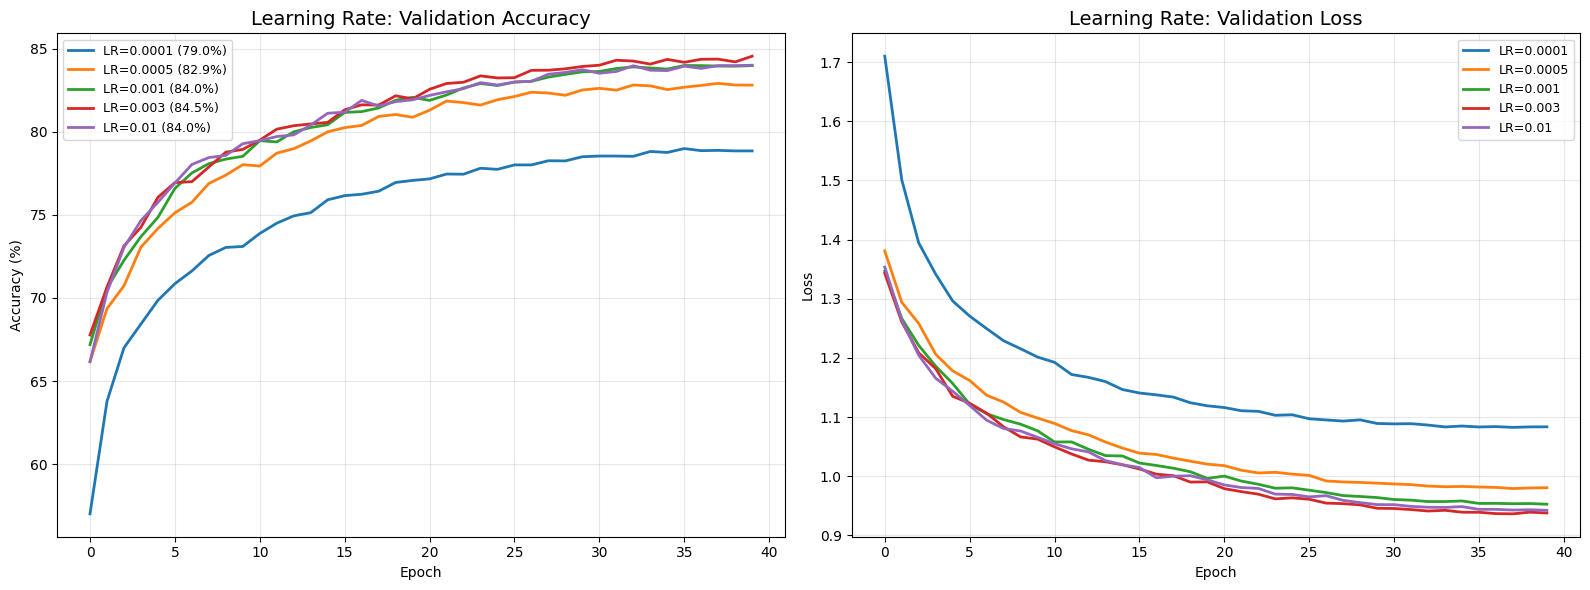

Saved analysis/exp_lr.png


In [12]:
import os
os.makedirs('analysis', exist_ok=True)

# Save Activation Function chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_activation.items():
    axes[0].plot(h['val_acc'], label=f"{name} ({h['best_val_acc']:.1f}%)", linewidth=2)
    axes[1].plot(h['val_loss'], label=name, linewidth=2)
axes[0].set_title('Activation Functions: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Activation Functions: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('analysis/exp_activations.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved analysis/exp_activations.png")

# Save Layer Depth chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_depth.items():
    short = f"{h['num_layers']}L ({h['best_val_acc']:.1f}%)"
    axes[0].plot(h['val_acc'], label=short, linewidth=2)
    axes[1].plot(h['val_loss'], label=f"{h['num_layers']}-Layer", linewidth=2)
axes[0].set_title('Layer Depth: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Layer Depth: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('analysis/exp_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved analysis/exp_depth.png")

# Save Learning Rate chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for name, h in results_lr.items():
    axes[0].plot(h['val_acc'], label=f"{name} ({h['best_val_acc']:.1f}%)", linewidth=2)
    axes[1].plot(h['val_loss'], label=name, linewidth=2)
axes[0].set_title('Learning Rate: Validation Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Learning Rate: Validation Loss', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('analysis/exp_lr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved analysis/exp_lr.png")